# 03 — Scheme Effect Regression

Panel regression estimating how offensive/defensive scheme labels relate to
Ivy-only win percentage, controlling for school and year fixed effects.

Also splits by coach tenure phase (years 1-2 vs 3+) to test whether scheme
fit improves over time.


In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.models import run_scheme_regression, plot_scheme_coefs, scheme_by_tenure

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [2]:
master = pd.read_csv('../data/processed/master_labeled.csv')
print(master.shape)
master[['school','year','off_scheme','def_scheme','ivy_win_pct']].head()

(80, 87)


,school,year,off_scheme,def_scheme,ivy_win_pct
0,brown,2014,Pro-Style / Power Run,3-4 / 3-3-5,0.428571
1,brown,2015,Spread Run,3-4 / 3-3-5,0.428571
2,brown,2016,Spread Run,3-4 / 3-3-5,0.428571
3,brown,2017,Spread Run,3-4 / 3-3-5,0.000000
4,brown,2018,Spread Run,3-4 / 3-3-5,0.000000


## Full panel regression

In [3]:
result = run_scheme_regression(master)
print(result['model_summary'].summary())

                            OLS Regression Results                            
Dep. Variable:            ivy_win_pct   R-squared:                       0.424
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     2.871
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           0.000801
Time:                        01:42:28   Log-Likelihood:                 14.995
No. Observations:                  80   AIC:                             14.01
Df Residuals:                      58   BIC:                             66.41
Df Model:                          21                                         
Covariance Type:                  HC3                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

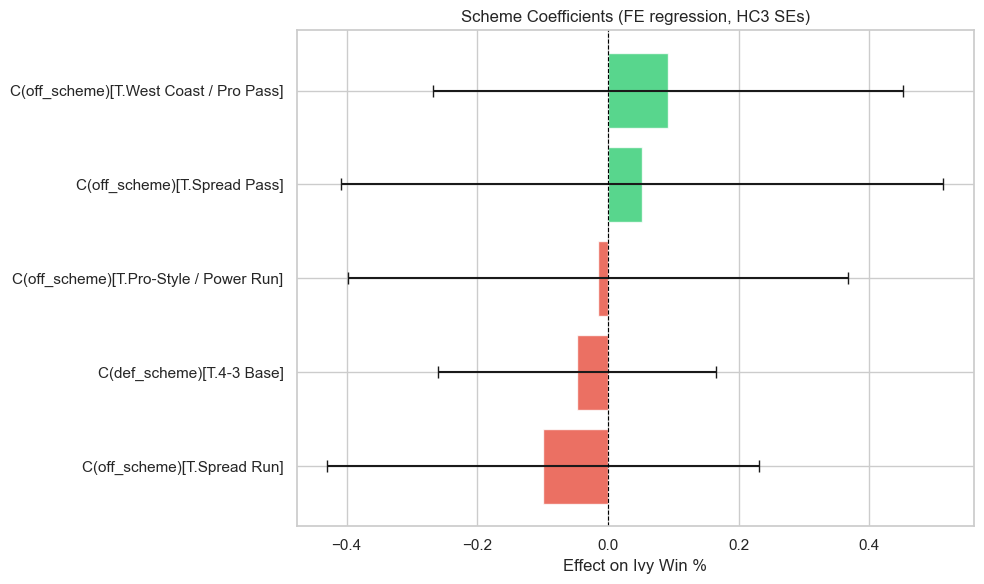

,term,coef,ci_lo,ci_hi,pvalue
0,Intercept,0.307455,-0.039732,0.654643,0.082623
1,C(off_scheme)[T.Pro-Style / Power Run],-0.015156,-0.397193,0.366880,0.938022
2,C(off_scheme)[T.Spread Pass],0.052133,-0.409015,0.513280,0.824646
3,C(off_scheme)[T.Spread Run],-0.098846,-0.429244,0.231553,0.557629
4,C(off_scheme)[T.West Coast / Pro Pass],0.092013,-0.267833,0.451859,0.616255
5,C(def_scheme)[T.4-3 Base],-0.047058,-0.260257,0.166141,0.665296


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_scheme_coefs(result['coef_df'], ax=ax)
plt.savefig('../data/processed/scheme_coefs.png', dpi=150)
plt.show()
result['coef_df']

## Win % by scheme
Raw averages — before controlling for school/year.

> **Interpretation caveat:** Scheme labels are not equally grounded across years.
> For **2014–2021**, labels are derived from roster composition only (`spread_factor` from skill-position weight, `front_heaviness` from DL/LB weight ratio) — box score data is unavailable for those years.
> For **2022–2024**, labels additionally use `pass_tendency`, `tempo`, and `explosiveness` from actual play data.
>
> This means "Pro-Style / Power Run" in 2017 means "heavy skill players" while the same label in 2023 means "low pass rate + low tempo + heavy skill players" — a richer and different signal.
> The null regression results (all scheme p > 0.5) should be read cautiously: they may reflect label inconsistency as much as a genuine absence of scheme effects.

In [5]:
off_summary = (
    master.groupby('off_scheme')['ivy_win_pct']
    .agg(['mean','std','count'])
    .rename(columns={'mean':'avg_win_pct','std':'std','count':'n'})
    .sort_values('avg_win_pct', ascending=False)
)
print('=== Offensive Scheme Win % ===')
display(off_summary)

def_summary = (
    master.groupby('def_scheme')['ivy_win_pct']
    .agg(['mean','std','count'])
    .rename(columns={'mean':'avg_win_pct','std':'std','count':'n'})
    .sort_values('avg_win_pct', ascending=False)
)
print('=== Defensive Scheme Win % ===')
display(def_summary)

=== Offensive Scheme Win % ===


,avg_win_pct,std,n
off_scheme,,,
Spread Pass,0.571429,0.142857,3
Pro-Style / Power Run,0.555556,0.245974,45
West Coast / Pro Pass,0.476190,0.218218,3
Spread Run,0.423077,0.303667,26
Air Raid / Spread RPO,0.285714,0.142857,3


=== Defensive Scheme Win % ===


,avg_win_pct,std,n
def_scheme,,,
4-3 Base,0.533333,0.255931,15
3-4 / 3-3-5,0.492308,0.269673,65


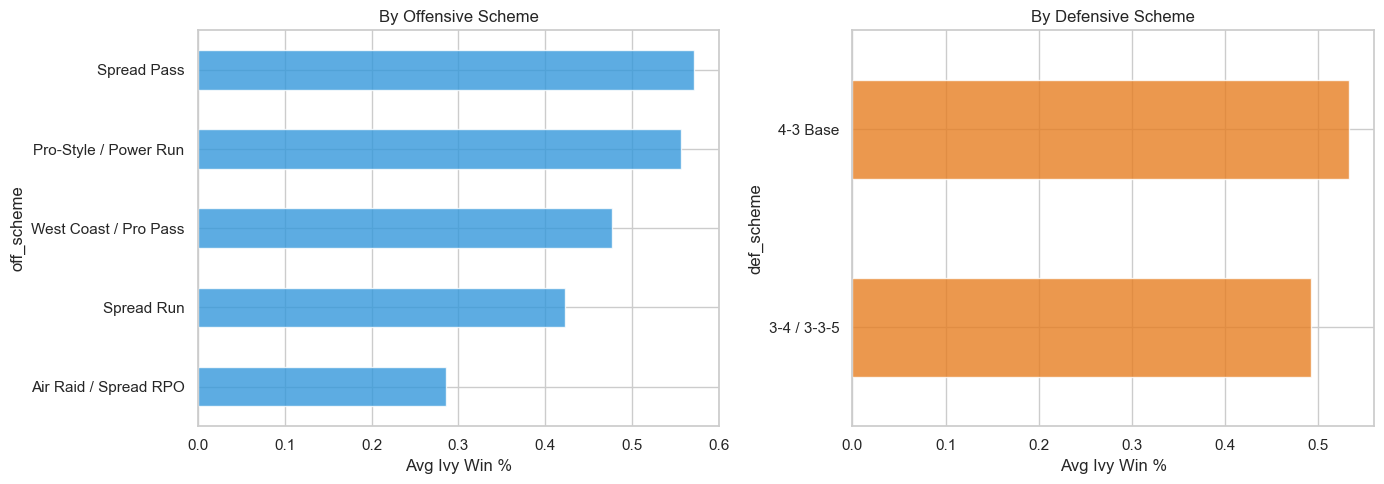

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
off_summary['avg_win_pct'].sort_values().plot.barh(ax=axes[0], color='#3498db', alpha=0.8)
axes[0].set_xlabel('Avg Ivy Win %')
axes[0].set_title('By Offensive Scheme')
def_summary['avg_win_pct'].sort_values().plot.barh(ax=axes[1], color='#e67e22', alpha=0.8)
axes[1].set_xlabel('Avg Ivy Win %')
axes[1].set_title('By Defensive Scheme')
plt.tight_layout()
plt.savefig('../data/processed/win_pct_by_scheme.png', dpi=150)
plt.show()

## Tenure analysis

Add coaching tenure data manually or via a CSV lookup table.
Format needed in `master`: columns `coach` and `coach_start_year`.

Example stub:

In [ ]:
# Load coach tenure lookup if it exists
import os
coach_path = '../data/raw/coaches.csv'
if os.path.exists(coach_path):
    coaches = pd.read_csv(coach_path)
    # Expected columns: school, year, coach, coach_start_year
    master_c = master.merge(coaches, on=['school','year'], how='left')
    tenure_table = scheme_by_tenure(master_c)
    display(tenure_table)
else:
    print("coaches.csv not found — create data/raw/coaches.csv with columns: school, year, coach, coach_start_year")
    print("Template saved to data/raw/coaches_template.csv")
    from src.scraper import IVY_SCHOOLS
    rows = []
    for school in IVY_SCHOOLS:
        for yr in range(2014, 2025):
            rows.append({'school': school, 'year': yr, 'coach': '', 'coach_start_year': ''})
    pd.DataFrame(rows).to_csv('../data/raw/coaches_template.csv', index=False)
    print('Template written. Fill in and rename to coaches.csv.')

## Style-score correlation with win %

In [ ]:
style_cols = ['pass_tendency','tempo','spread_factor','explosiveness','aggression','front_heaviness']
available = [c for c in style_cols if c in master.columns and master[c].notna().sum() > 5]

if available and 'ivy_win_pct' in master.columns:
    # Count non-null rows per score so we can annotate the chart
    n_per = {c: master[c].notna().sum() for c in available}

    corrs = master[available + ['ivy_win_pct']].corr()['ivy_win_pct'].drop('ivy_win_pct')
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corrs.sort_values()]
    corrs.sort_values().plot.barh(ax=ax, color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Pearson r with Ivy Win %')

    # Annotate each bar with its sample size
    for i, col in enumerate(corrs.sort_values().index):
        n = n_per[col]
        ax.text(0.01, i, f'n={n}', va='center', fontsize=8, color='black')

    ax.set_title(
        'Style Score Correlations with Ivy Win %\n'
        '⚠ pass_tendency / tempo / explosiveness: n=24 (2022–2024 only); '
        'spread_factor / front_heaviness: n≈70 (2014–2024)'
    )
    plt.tight_layout()
    plt.savefig('../data/processed/style_correlations.png', dpi=150)
    plt.show()
    display(corrs.sort_values(ascending=False).rename('Pearson r').to_frame().assign(n=[n_per[c] for c in corrs.sort_values(ascending=False).index]))
else:
    print('Insufficient style data for correlation analysis.')